<div style="border-bottom: 2px solid #e8a435; padding-bottom: 20px; margin-bottom: 30px;">
<div style="display: flex; align-items: center; gap: 16px;">
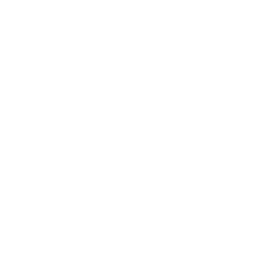
<div>
<h1 style="margin: 0; font-family: 'Inter', 'Helvetica Neue', sans-serif; font-weight: 700; color: #1a1a2e; font-size: 28px; letter-spacing: -0.5px;">Hospital Department Resource Utilization — Horizontal Bar Chart</h1>
<p style="margin: 4px 0 0 0; font-family: 'Inter', 'Helvetica Neue', sans-serif; color: #6c6c8a; font-size: 14px;">Jenner Analytics Ltd &nbsp;|&nbsp; Healthcare / Hospital Operations &nbsp;|&nbsp; March 2026</p>
</div>
</div>
</div>

## 执行摘要

本示例使用 **PROC GCHART** 的水平条形图（HBAR）功能，剖析2026年第一季度六个临床科室的工时分布。一份包含**90条班次记录**（每个科室15条）的模拟人员排班日志驱动了三种视图：按总工时排序的条形图、各科室平均班次时长，以及按资源类别和班次分组的HBAR图。`SUMVAR=` 累加实际劳动工时而非记录计数，`TYPE=SUM`/`TYPE=MEAN` 切换响应统计量，`DESCENDING` 对科室进行降序排列，`GROUP=` 为第二维度绘制相邻的分组条形图。

该输出支撑季度运营效率评审：揭示哪些科室消耗劳动工时最多、哪些运行班次最长，以及全天候高强度科室与日间导向型服务在白班/中班/夜班人员配置模式上的差异。

## 数据来源

| 数据源 | 说明 | 记录数 |
|--------|-------------|--------|
| WORK.STAFFING_LOG | 含工时的单条班次劳动记录 | 90 |
| WORK.DEPT_SUMMARY | 科室层级总工时与平均班次时长 | 6 |

---

In [1]:
/* --------------------------------------------------------
   Generate a synthetic hospital staffing labor log.
   Q1 2026: 6 clinical departments, 4 resource categories,
   3 shifts. Sized to 15 shift records per department
   (90 total) so the full department roster stays visible.
   -------------------------------------------------------- */
数据 work.staffing_log;
    调用 streaminit(20260601);
    长度 department $20 resource_type $20 shift $10;

    /* resource-category mix (nursing-heavy clinical staffing) */
    数组 resw[4] _temporary_ (0.50 0.20 0.20 0.10);

    /* baseline shift mix, tilted toward Night for 24/7 units */
    数组 shfw[3] _temporary_ (0.45 0.30 0.25);
    数组 nightlift[6] _temporary_
        (0.18 0.00 0.22 -0.05 -0.05 0.05);

    循环 di = 1 到 6;
        如果 di = 1 那么 department = '急诊科';
        否则 如果 di = 2 那么 department = '外科';
        否则 如果 di = 3 那么 department = '重症监护室';
        否则 如果 di = 4 那么 department = '儿科';
        否则 如果 di = 5 那么 department = '肿瘤科';
        否则 department = '产科';
        循环 rec = 1 到 15;

            /* resource type via weighted draw */
            u = rand('uniform'); cum = 0;
            循环 r = 1 到 4;
                cum + resw[r];
                如果 u <= cum 那么 循环;
                    如果 r = 1 那么 resource_type = '护理';
                    否则 如果 r = 2 那么 resource_type = '医师';
                    否则 如果 r = 3 那么 resource_type = '专职医疗';
                    否则 resource_type = '后勤支持';
                    退出;
                结束;
            结束;

            /* shift via department-specific night tilt */
            w1 = shfw[1] - nightlift[di] / 2;
            w2 = shfw[2] - nightlift[di] / 2;
            u = rand('uniform');
            如果 u <= w1 那么 shift = '白班';
            否则 如果 u <= w1 + w2 那么 shift = '中班';
            否则 shift = '夜班';

            /* hours: physicians and surgery run longer shifts */
            BASE = 8;
            如果 resource_type = '医师' 那么 BASE = BASE + 1.5;
            如果 department = '外科'      那么 BASE = BASE + 1.0;
            hours_worked = round(BASE + rand('normal', 0, 0.8), 0.25);
            如果 hours_worked < 4 那么 hours_worked = 4;

            输出;
        结束;
    结束;
    保留 department resource_type shift hours_worked;
运行;


NOTE: DATA work.staffing_log


NOTE: Wrote work.staffing_log (90 rows, 4 columns).
NOTE: DATA elapsed:
  wall  0.03 seconds
  cpu   0.03 seconds


In [2]:
/* --------------------------------------------------------
   Department-level totals and mean shift length,
   ranked by total labor hours.
   -------------------------------------------------------- */
过程 SQL;
    CREATE TABLE work.dept_summary AS
    选择 department,
           sum(hours_worked)  AS total_hours   格式=8.2,
           count(*)           AS shift_count,
           mean(hours_worked) AS avg_shift_hrs  格式=6.2
    FROM work.staffing_log
    GROUP 按照 department
    ORDER 按照 total_hours DESC;
QUIT;

过程 打印 数据=work.dept_summary noobs 标签;
    标签 total_hours   = '总工时'
          shift_count   = '班次数'
          avg_shift_hrs = '平均班次时长(小时)';
    标题 '科室工时汇总 - 2026年第一季度';
运行;
标题;

                                                   科室工时汇总 - 2026年第一季度                                                   

     department        总工时        班次数                  平均班次时长(小时)
外科                  136.25         15                        9.08
重症监护室               128.50         15                        8.57
产科                  127.75         15                        8.52
儿科                  124.75         15                        8.32
肿瘤科                 123.75         15                        8.25
急诊科                 119.25         15                        7.95




NOTE: PROC SQL 

NOTE: Table work.dept_summary created.
NOTE: PROC SQL statement used.
NOTE: PROC PRINT data=work.dept_summary

NOTE: PROC PRINT completed: 6 observations printed, 4 variables


---

                                                         各科室工时                                                          

                                                  The MEANS Procedure

                                            Analysis Variable : hours_worked

        department                 Sum           Mean          N Obs
        ------------------------------------------------------------
        产科                      127.75           8.52             15
        儿科                      124.75           8.32             15
        外科                      136.25           9.08             15
        急诊科                     119.25           7.95             15
        肿瘤科                     123.75           8.25             15
        重症监护室                   128.50           8.57             15
        ------------------------------------------------------------

                                                        各科室班次分布                                            


NOTE: PROC MEANS
NOTE: PROC MEANS statement used.
NOTE: PROC FREQ
NOTE: ODS plot written: freq_mosaic_department_shift.spec.json
NOTE: PROC FREQ statement used.


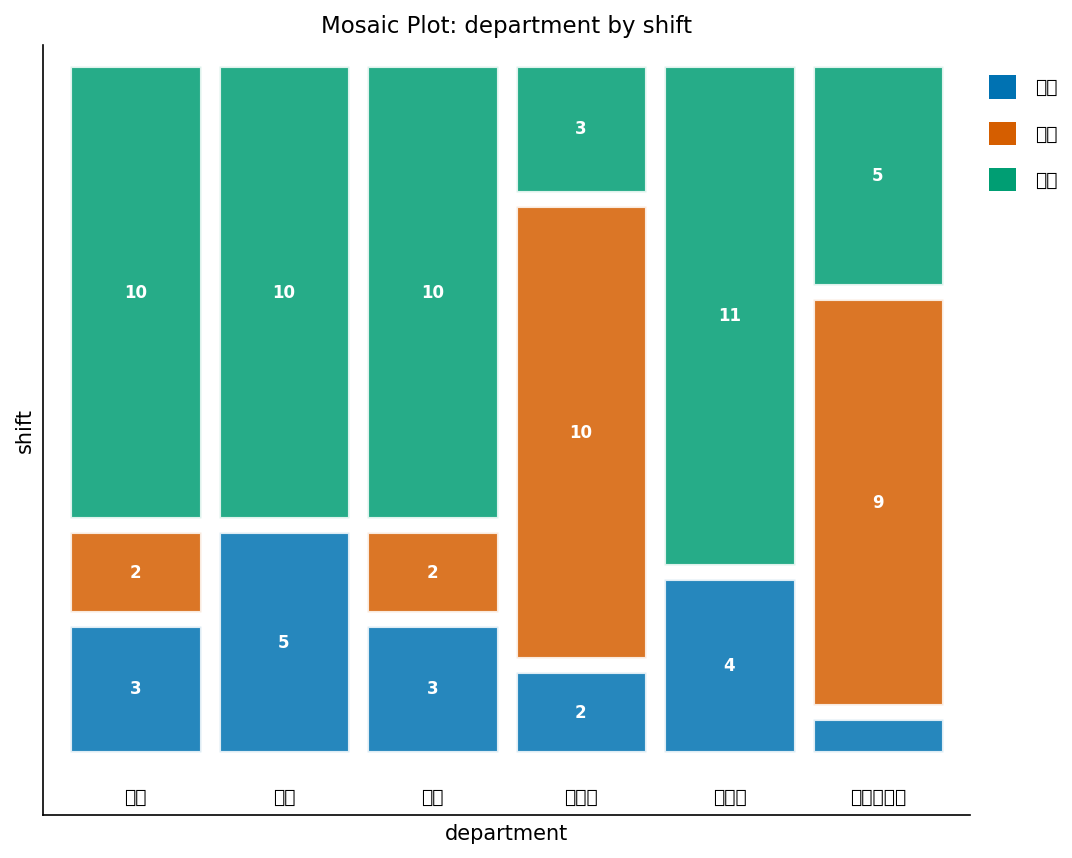

In [3]:
/* --------------------------------------------------------
   Baseline tables: labor hours by department, and the
   day / swing / night shift distribution per department.
   -------------------------------------------------------- */
过程 均值 数据=work.staffing_log sum mean n maxdec=2;
    分类 department;
    变量 hours_worked;
    标题 '各科室工时';
运行;

过程 频率 数据=work.staffing_log;
    TABLES department * shift / norow nocol nopercent;
    标题 '各科室班次分布';
运行;
标题;

---


NOTE: PROC GCHART data=work.staffing_log

NOTE: ODS plot written: gchart_hbar.spec.json


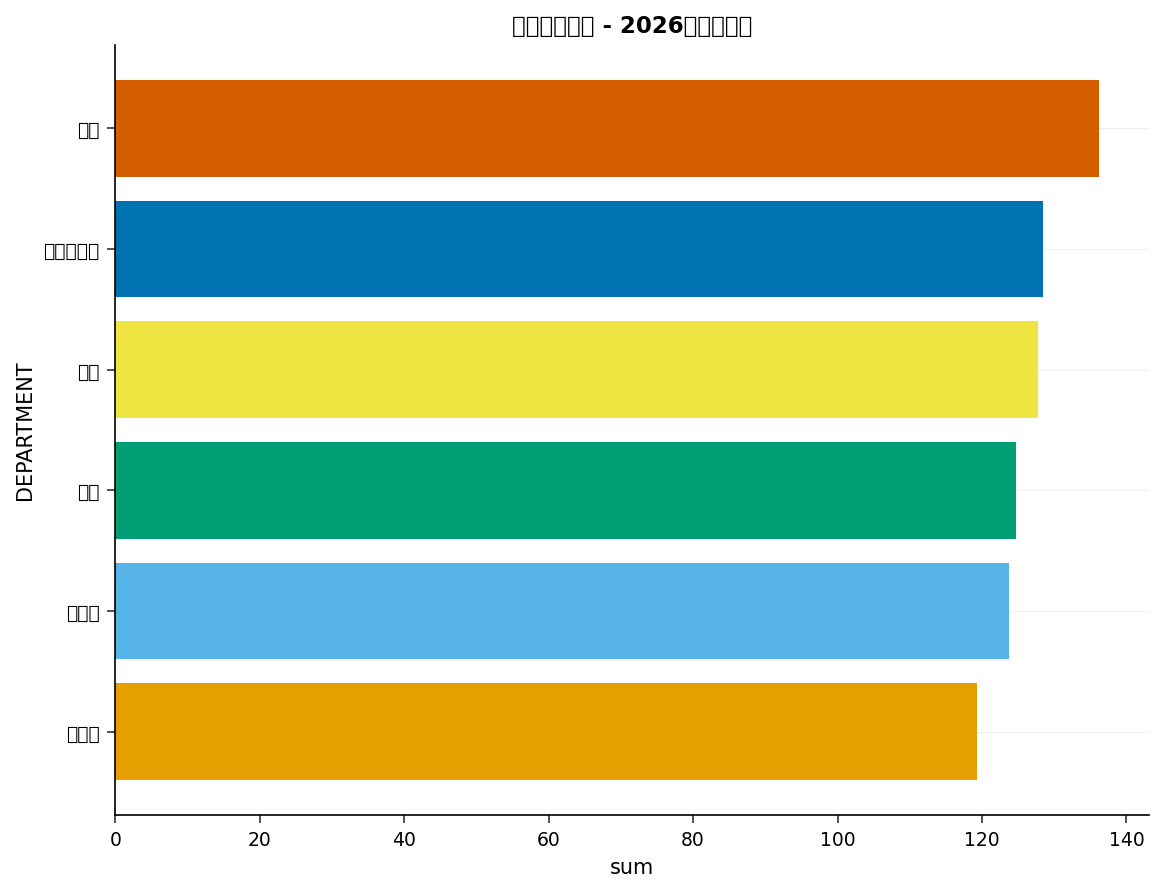

In [4]:
/* --------------------------------------------------------
   Overview HBAR: total labor hours by department.
   SUMVAR= accumulates hours; DESCENDING ranks the bars.
   -------------------------------------------------------- */
过程 GCHART 数据=work.staffing_log;
    HBAR department / SUMVAR=hours_worked
                      type=sum
                      DESCENDING;
    标题 '各科室总工时 - 2026年第一季度';
运行;
QUIT;
标题;

### 按资源类别拆分各科室

`GROUP=` 为每个科室绘制一组相邻的水平条形图，每种资源类别一根条形。由于启用了 `SUMVAR=hours_worked`，每根条形衡量的是累计工时而非记录数，因此该图展示了护理、医师、专职医疗与后勤支持工时在*每个科室内部*的对比。

In [5]:
/* --------------------------------------------------------
   PATTERN statements: coordinated 4-color palette
   one pattern per resource type subgroup
   -------------------------------------------------------- */
pattern1 VALUE=solid color=cx2C5F8A;   /* Nursing -- deep blue   */
pattern2 VALUE=solid color=cx28A745;   /* Physician -- green     */
pattern3 VALUE=solid color=cxE8650A;   /* Allied Health -- amber */
pattern4 VALUE=solid color=cx6C757D;   /* Support Staff -- gray  */

                                                     各科室按资源类别划分的工时                                                      


数据来源：人力资源管理系统 | 报告期：2026年1-3月



NOTE: Option TITLE changed to 各科室按资源类别划分的工时.
NOTE: Option FOOTNOTE changed to 数据来源：人力资源管理系统 | 报告期：2026年1-3月.
NOTE: PROC GCHART data=work.staffing_log

NOTE: ODS plot written: gchart_hbar.spec.json


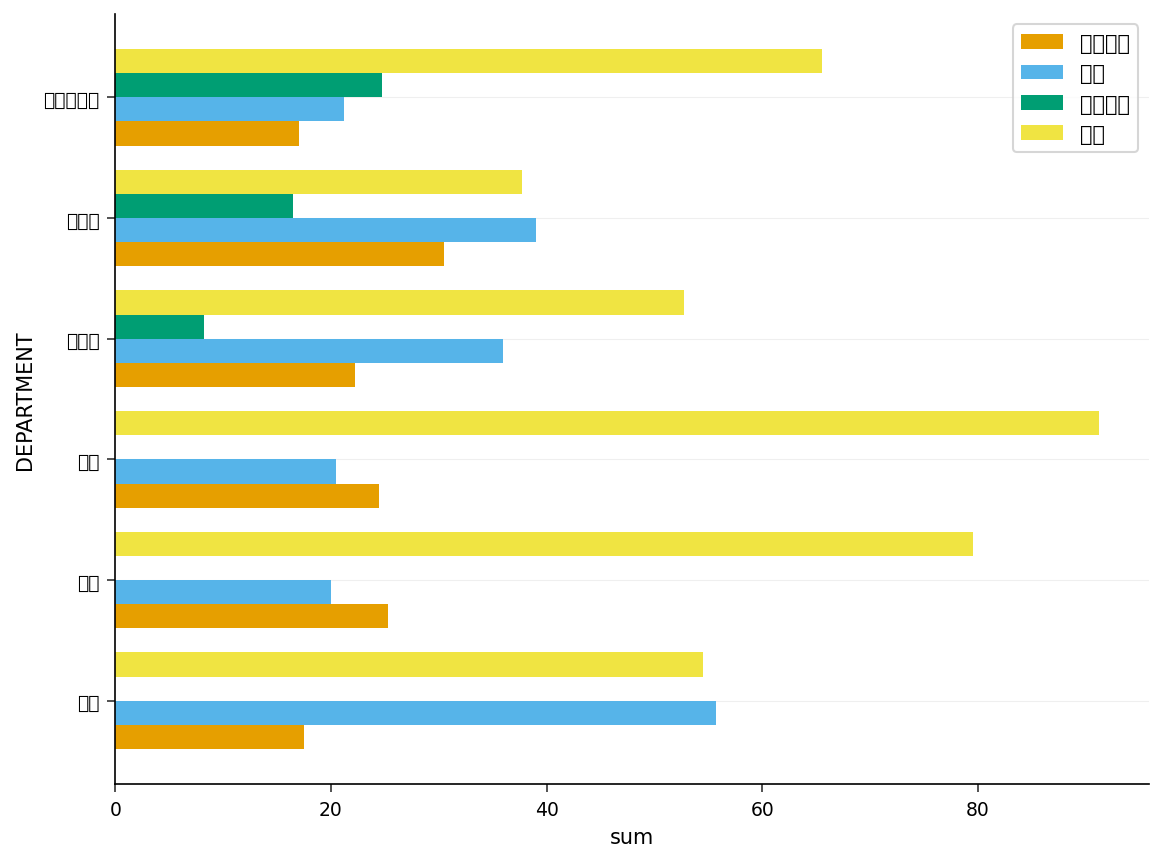

In [6]:
/* --------------------------------------------------------
   HBAR grouped by resource category (GROUP=).
   Each department becomes a cluster of bars -- one per
   resource type -- measured in accumulated labor hours.
   -------------------------------------------------------- */
标题 '各科室按资源类别划分的工时';
footnote JUSTIFY=LEFT
    '数据来源：人力资源管理系统 | 报告期：2026年1-3月';

过程 GCHART 数据=work.staffing_log;
    HBAR department / GROUP=resource_type
                      SUMVAR=hours_worked
                      type=sum;
运行;
QUIT;

标题; footnote;

                                                      各科室按班次划分的工时                                                       


分组条形图展示各科室白班/中班/夜班的工时构成



NOTE: Option TITLE changed to 各科室按班次划分的工时.
NOTE: Option FOOTNOTE changed to 分组条形图展示各科室白班/中班/夜班的工时构成.
NOTE: PROC GCHART data=work.staffing_log

NOTE: ODS plot written: gchart_hbar.spec.json


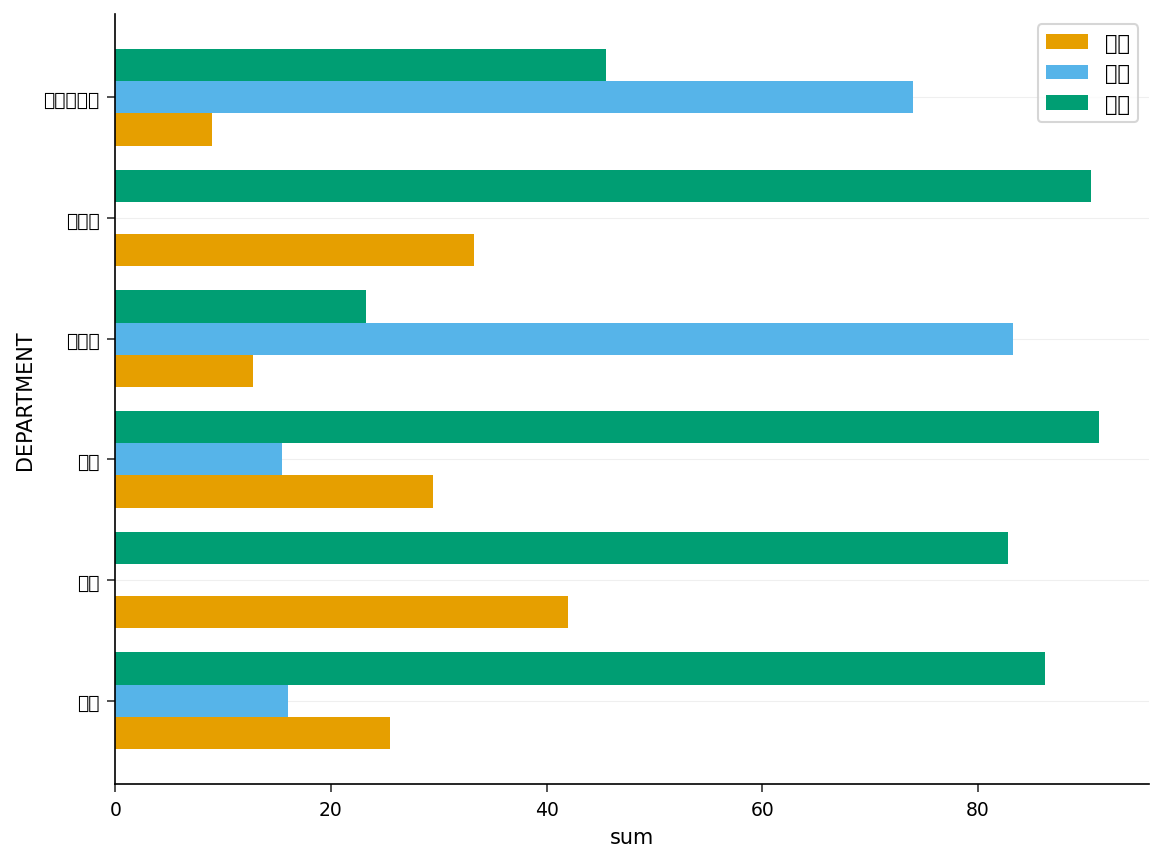

In [7]:
/* --------------------------------------------------------
   HBAR grouped by shift (GROUP=).
   Separates Day / Swing / Night labor hours within each
   department -- highlighting the 24/7 acuity units.
   -------------------------------------------------------- */
标题 '各科室按班次划分的工时';
footnote JUSTIFY=LEFT
    '分组条形图展示各科室白班/中班/夜班的工时构成';

过程 GCHART 数据=work.staffing_log;
    HBAR department / GROUP=shift
                      SUMVAR=hours_worked
                      type=sum;
运行;
QUIT;

标题; footnote;


NOTE: PROC GCHART data=work.staffing_log

NOTE: ODS plot written: gchart_hbar.spec.json


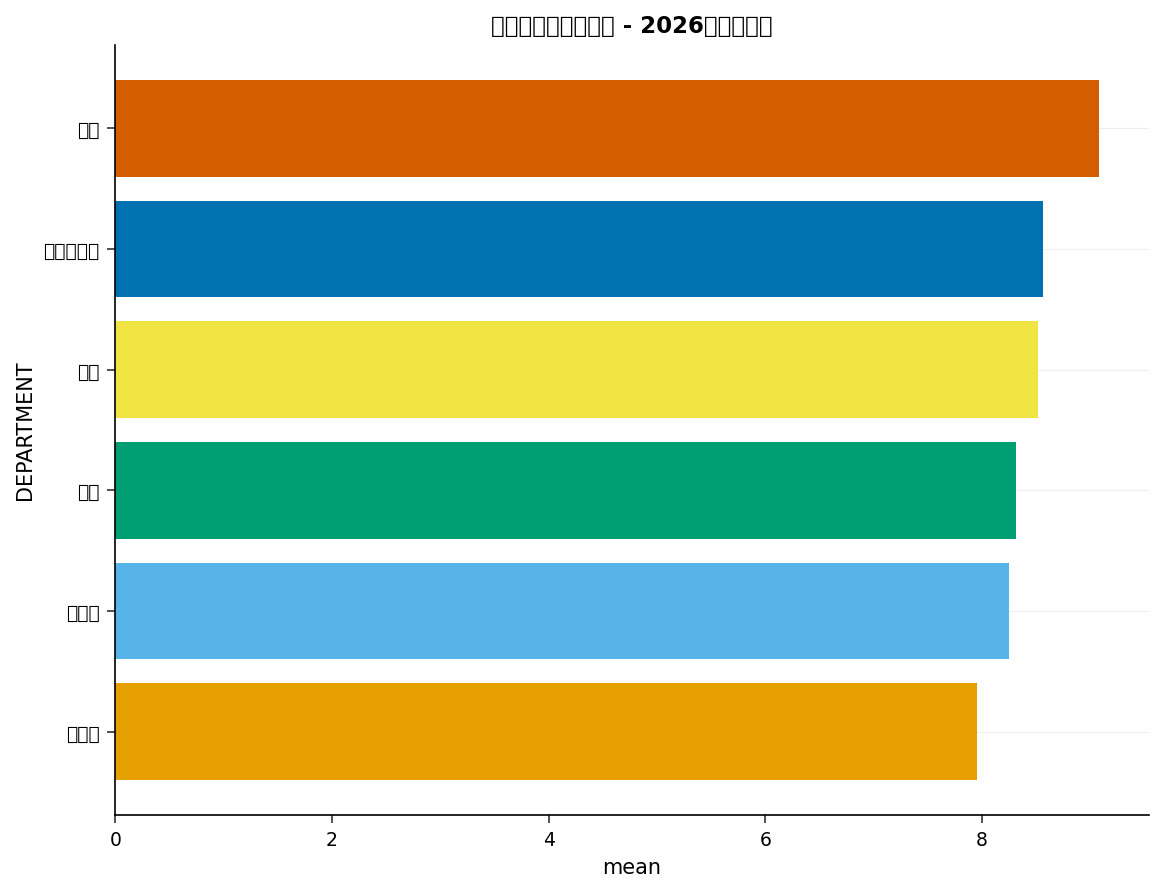

In [8]:
/* --------------------------------------------------------
   Mean shift length per department (TYPE=MEAN).
   Reveals whether a department runs long shifts or many
   shorter ones, independent of total volume.
   -------------------------------------------------------- */
过程 GCHART 数据=work.staffing_log;
    HBAR department / SUMVAR=hours_worked
                      type=mean
                      DESCENDING;
    标题 '各科室平均班次时长 - 2026年第一季度';
运行;
QUIT;
标题;

---

### 结果解读

在这90条班次记录中，各科室总工时集中在一个较窄区间：从**急诊科**的**119.25**到**外科**的**136.25**——因为本期每个科室都配有相同的15个班次，所以排名反映的是**班次时长**而非班次数量。**外科**在总工时图和平均班次时长图中均居首位，平均每班**9.08小时**，这与手术病例耗时更长、需要更多医师配置相符。**急诊科**尽管是最繁忙的单位之一，但其工时排名垫底（平均**7.95**小时），因为其工作以更短、更高周转率的班次完成。

按班次分组的HBAR图与马赛克面板揭示了对运营至关重要的现象：**急诊科和重症监护室以夜班为主**——15个班次中分别有10个和9个落在夜班——而**肿瘤科和儿科完全没有夜班**，主要集中在白班（分别为11个和10个白班）。这一分化反映了真实的医院人员配置模式：全天候高强度科室需要昼夜轮值，而肿瘤输液和普通儿科则属于日间服务。资源类别面板证实了每个科室都以**护理为主导**的人员构成，医师和专职医疗工时构成了次级层级。

对于第二季度的排班评审，急诊科和重症监护室的夜班集中度是需要重点关注的指标：这里是加班费和疲劳管理成本积累的地方，也是排班调整对预算影响最大的地方。

---

In [9]:
/* --------------------------------------------------------
   Export the department summary for the workforce
   planning system.
   -------------------------------------------------------- */
过程 EXPORT 数据=work.dept_summary
    OUTFILE='q1_dept_labor_summary.csv'
    DBMS=csv REPLACE;
运行;


NOTE: PROC EXPORT data=work.dept_summary outfile=q1_dept_labor_summary.csv

NOTE: Exported 6 rows to q1_dept_labor_summary.csv.


---
<div style="border-top: 1px solid #e0e0e0; padding-top: 16px; margin-top: 20px; display: flex; justify-content: space-between; align-items: center;">
<div style="font-family: 'Inter', 'Helvetica Neue', sans-serif; color: #9e9e9e; font-size: 12px;">
&copy; 2026 Jenner Analytics Ltd &nbsp;&bull;&nbsp; Confidential
</div>
<div style="font-family: 'Inter', 'Helvetica Neue', sans-serif; color: #9e9e9e; font-size: 12px;">
Powered by <a href="https://docs.jenneranalytics.com" style="color: #e8a435; text-decoration: none;">Jenner</a>
</div>
</div>